In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

In [2]:
df = pd.read_csv("../data/cleaned_sales_data.csv")

df['Order_Date'] = pd.to_datetime(df['Order_Date'])

df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub-Category,Product_Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
sales_forecast = df.groupby('Order_Date')['Sales'].sum().reset_index()

sales_forecast.columns = ['ds', 'y']

sales_forecast.head()

,ds,y
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [4]:
model = Prophet()

model.fit(sales_forecast)

03:09:33 - cmdstanpy - INFO - Chain [1] start processing
03:09:35 - cmdstanpy - INFO - Chain [1] done processing


In [5]:
future = model.make_future_dataframe(periods=90)

future.tail()

,ds
1314,2019-03-26
1315,2019-03-27
1316,2019-03-28
1317,2019-03-29
1318,2019-03-30


In [6]:
forecast = model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2015-01-03,1407.906749,-1125.209869,4092.277394,1407.906749,1407.906749,102.920045,102.920045,102.920045,370.867035,370.867035,370.867035,-267.946990,-267.946990,-267.946990,0.0,0.0,0.0,1510.826794
1,2015-01-04,1408.155499,-1550.306660,3931.707903,1408.155499,1408.155499,-233.647381,-233.647381,-233.647381,130.754766,130.754766,130.754766,-364.402147,-364.402147,-364.402147,0.0,0.0,0.0,1174.508118
2,2015-01-05,1408.404248,-1779.010907,3532.441074,1408.404248,1408.404248,-448.132964,-448.132964,-448.132964,7.146619,7.146619,7.146619,-455.279583,-455.279583,-455.279583,0.0,0.0,0.0,960.271284
3,2015-01-06,1408.652997,-1666.466817,4070.992329,1408.652997,1408.652997,-192.005261,-192.005261,-192.005261,347.357551,347.357551,347.357551,-539.362811,-539.362811,-539.362811,0.0,0.0,0.0,1216.647736
4,2015-01-07,1408.901746,-2005.989627,3283.354830,1408.901746,1408.901746,-718.390642,-718.390642,-718.390642,-102.828226,-102.828226,-102.828226,-615.562416,-615.562416,-615.562416,0.0,0.0,0.0,690.511104


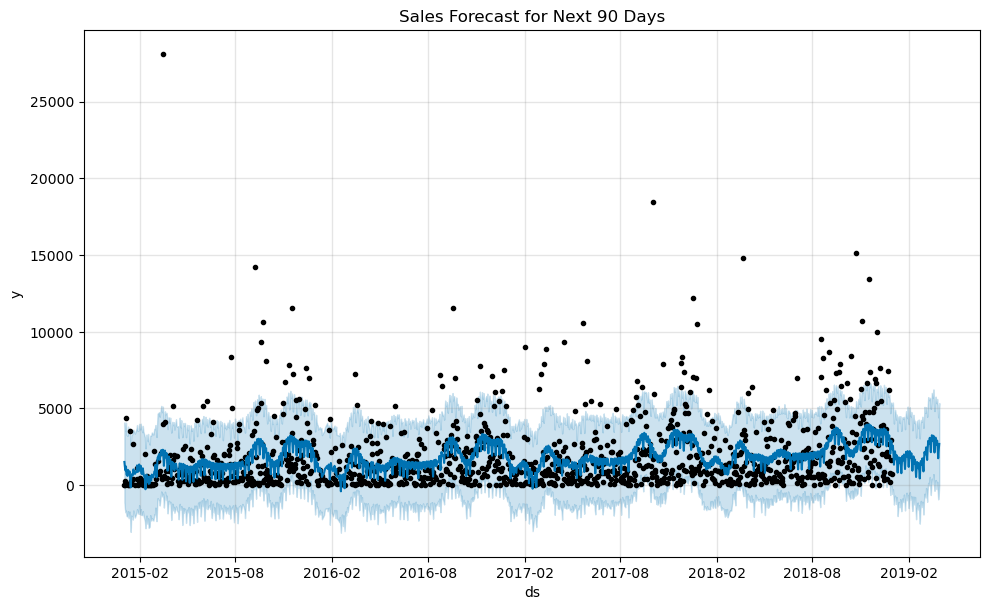

In [7]:
fig = model.plot(forecast)

plt.title("Sales Forecast for Next 90 Days")

plt.show()

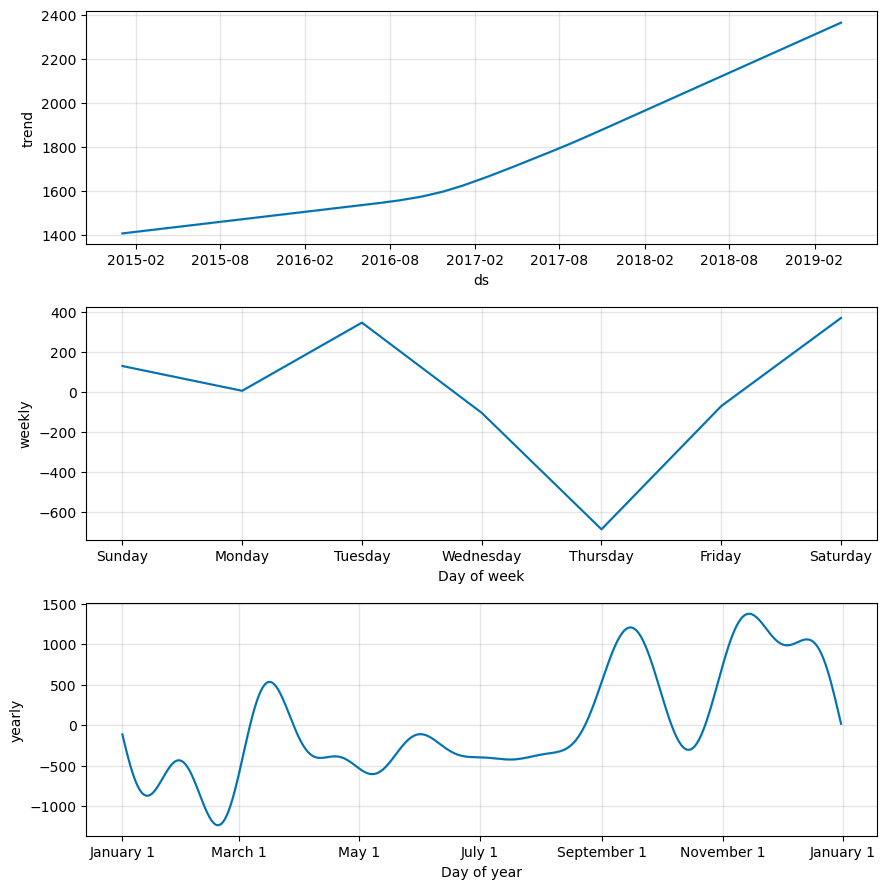

In [8]:
fig2 = model.plot_components(forecast)

plt.show()

In [9]:
forecast.to_csv("../data/sales_forecast.csv", index=False)

print("Forecast data saved successfully!")

Forecast data saved successfully!
